In [24]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [22]:
data_path = "../data/raw_data/"

split = ["train_dataset"]
split_path = os.path.join(data_path, split[0])
offices = os.listdir(split_path)
print(f"Number of sequences: {len(offices)}")


Number of sequences: 60


In [ ]:
seq_len = []
for folder in offices:
    file_path = os.path.join(split_path, folder, "rawdata.npy")
    demo_data = np.load(file_path)
    seq_len.append(demo_data.shape[0])

seq_len.sort()
seq_len[0], seq_len[-1]

(44452, 138073)

In [20]:
demo = np.load(file_path)
demo[:200]

array([[ 1.68716189e+09, -1.68542377e-03, -1.34745301e-06, ...,
        -2.40000019e+01,  1.29166675e+00, -7.18333387e+00],
       [ 1.68716189e+09, -9.78409873e-05,  2.83515563e-04, ...,
        -2.41666679e+01,  1.12500000e+00, -6.80833387e+00],
       [ 1.68716189e+09, -9.78409873e-05,  2.83515563e-04, ...,
        -2.41666679e+01,  1.12500000e+00, -6.80833387e+00],
       ...,
       [ 1.68716189e+09, -2.54161005e-03, -1.55887774e-03, ...,
        -2.40833340e+01,  2.08333349e+00, -6.97500038e+00],
       [ 1.68716189e+09, -2.54161005e-03, -1.55887774e-03, ...,
        -2.40833340e+01,  2.08333349e+00, -6.97500038e+00],
       [ 1.68716189e+09, -9.82951225e-04,  1.37180006e-03, ...,
        -2.34166679e+01,  2.29166675e+00, -7.60000038e+00]],
      shape=(200, 10))

In [36]:
def extract_windows(imu, quat, window_size=100, stride=20):
    X, Y = [], []
    N = imu.shape[0]
    last_start = N - window_size

    if last_start < 0:
        return None, None
    
    for start in range(0, last_start+1, stride):
        imu_window = imu[start : start + window_size]
        quat_target = quat[start + window_size -1]

        X.append(imu_window)
        Y.append(quat_target)

    return np.stack(X), np.stack(Y)
    ...

for folder in offices:
    rawfile_path = os.path.join(split_path, folder, "rawdata.npy")
    gt_path = os.path.join(split_path, folder, "groundtruth.npy")

    imu_all = np.load(rawfile_path)
    imu = imu_all[:, 1:7]
    quat = np.load(gt_path)[:, 1:]

    print(f"IMU data shape: {imu.shape} \ngt data shape: {quat.shape}")

    X, Y = extract_windows(imu, quat)
    print(X.shape, Y.shape)

    break


IMU data shape: (44452, 6) 
gt data shape: (44452, 4)
(2218, 100, 6) (2218, 4)


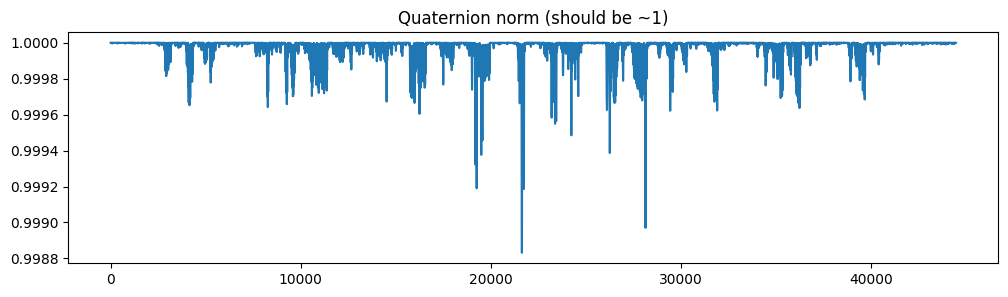

In [37]:
plt.figure(figsize=(12,3))
plt.plot(np.linalg.norm(quat, axis=1))
plt.title("Quaternion norm (should be ~1)")
plt.show()


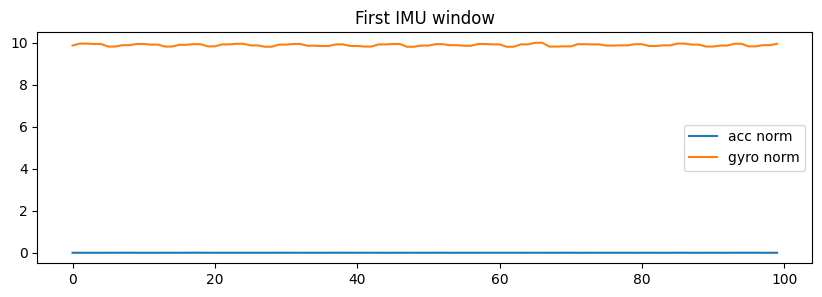

In [38]:
plt.figure(figsize=(10,3))
plt.plot(np.linalg.norm(X[0][:, :3], axis=1), label="acc norm")
plt.plot(np.linalg.norm(X[0][:, 3:], axis=1), label="gyro norm")
plt.legend()
plt.title("First IMU window")
plt.show()


In [47]:
all_X = []
all_y = []
skipped = 0

for folder in offices:
    rawfile_path = os.path.join(split_path, folder, "rawdata.npy")
    gt_path = os.path.join(split_path, folder, "groundtruth.npy")

    imu = np.load(rawfile_path)[:, 1:7]
    quat = np.load(gt_path)[:, 1:]

    X, y = extract_windows(imu, quat)

    if X is None:
        skipped += 1
        continue

    all_X.append(X)
    all_y.append(y)

print(f"Skipped sequences (too short): {skipped}")


Skipped sequences (too short): 0


In [48]:
X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

X_all.shape, y_all.shape

((327631, 100, 6), (327631, 4))

In [49]:
X_all[:, :, :3].shape, X_all[:, :, :3].reshape(-1,3).shape

((327631, 100, 3), (32763100, 3))

In [51]:
X_all[:, :, 3:].shape, X_all[:, :, 3:].reshape(-1, 3).shape

((327631, 100, 3), (32763100, 3))

In [52]:
acc = X_all[:, :, :3].reshape(-1, 3)
gyro = X_all[:, :, 3:].reshape(-1, 3)

acc_mean, acc_std = acc.mean(0), acc.std(0)
gyro_mean, gyro_std = gyro.mean(0), gyro.std(0)

In [53]:
X_all_norm = X_all.copy()

X_all_norm[:, :, :3] = (X_all[:, :, :3] - acc_mean) / acc_std
X_all_norm[:, :, 3:] = (X_all[:, :, 3:] - gyro_mean) / gyro_std

np.mean(X_all_norm), np.std(X_all_norm)

(np.float64(-6.421850784701565e-13), np.float64(0.9999999999999747))